In [1]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

print("Sẵn sàng cho Autoencoder!")

Sẵn sàng cho Autoencoder!


In [3]:
# Cell 2: Mount Drive (Bỏ qua nếu đã làm)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Cell 2: Đọc dữ liệu Train (Chỉ Normal) và Test (Tổng hợp)
# Cập nhật đường dẫn Drive của bạn nếu cần
train_file = '/content/drive/MyDrive/Data_InSDN/Normal_Train_Autoencoder.csv'
test_file = '/content/drive/MyDrive/Data_InSDN/Cleaned_InSDN_OpenFlow_Dataset.csv'

print("Đang đọc dữ liệu...")
df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

print(f"Số lượng mẫu Train (Chỉ Normal): {df_train.shape[0]}")
print(f"Số lượng mẫu Test (Có cả Normal & Tấn công): {df_test.shape[0]}")

Đang đọc dữ liệu...
Số lượng mẫu Train (Chỉ Normal): 68424
Số lượng mẫu Test (Có cả Normal & Tấn công): 343889


In [5]:
# Cell 3: Chuẩn bị DataLoader
features = ['duration', 'packet_count', 'byte_count', 'byte_rate', 'packet_rate', 'Protocol']

# 1. Tập Train (Chỉ lấy đặc trưng, không cần nhãn vì là Unsupervised)
X_train = df_train[features].values
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

# 2. Tập Test (Lấy đặc trưng và nhãn để đánh giá)
X_test = df_test[features].values
y_test = df_test['Label_Binary'].values # 0: Normal, 1: Anomaly
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# PyTorch Dataset
class AETrainDataset(Dataset):
    def __init__(self, X):
        self.X = X
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.X[idx] # Autoencoder: Input cũng chính là Target

batch_size = 256
train_loader = DataLoader(AETrainDataset(X_train_tensor), batch_size=batch_size, shuffle=True)

# Tập Test đưa vào đánh giá 1 lần (không cần dataloader)
X_test_tensor = X_test_tensor.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

print("Đã chuẩn bị xong dữ liệu Tensor!")

Đã chuẩn bị xong dữ liệu Tensor!


In [6]:
# Cell 4: Thiết kế Autoencoder
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DeepAutoencoder, self).__init__()

        # Lớp mã hóa (Encoder)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3) # Latent Space (Không gian ẩn)
        )

        # Lớp giải mã (Decoder)
        self.decoder = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.Sigmoid() # Sigmoid vì dữ liệu của bạn đã được scale [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = len(features) # 6
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng phần cứng: {device}")

model_ae = DeepAutoencoder(input_dim).to(device)

Đang sử dụng phần cứng: cuda


In [7]:
# Cell 5: Compile model
# Dùng MSE (Mean Squared Error) để đo Lỗi tái tạo
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.001)

Bắt đầu huấn luyện Autoencoder (Chỉ trên dữ liệu Bình thường)...
Epoch [1/15], Loss (Lỗi tái tạo): 0.110401
Epoch [2/15], Loss (Lỗi tái tạo): 0.021093
Epoch [3/15], Loss (Lỗi tái tạo): 0.009897
Epoch [4/15], Loss (Lỗi tái tạo): 0.007004
Epoch [5/15], Loss (Lỗi tái tạo): 0.004476
Epoch [6/15], Loss (Lỗi tái tạo): 0.003594
Epoch [7/15], Loss (Lỗi tái tạo): 0.003197
Epoch [8/15], Loss (Lỗi tái tạo): 0.002865
Epoch [9/15], Loss (Lỗi tái tạo): 0.002631
Epoch [10/15], Loss (Lỗi tái tạo): 0.002372
Epoch [11/15], Loss (Lỗi tái tạo): 0.002073
Epoch [12/15], Loss (Lỗi tái tạo): 0.001930
Epoch [13/15], Loss (Lỗi tái tạo): 0.001810
Epoch [14/15], Loss (Lỗi tái tạo): 0.001702
Epoch [15/15], Loss (Lỗi tái tạo): 0.001617


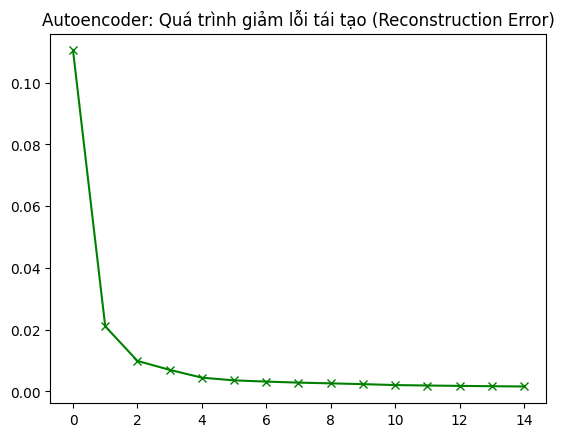

In [8]:
# Cell 6: Huấn luyện (Chỉ học mạng Normal)
num_epochs = 15
train_losses = []

print("Bắt đầu huấn luyện Autoencoder (Chỉ trên dữ liệu Bình thường)...")
for epoch in range(num_epochs):
    model_ae.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model_ae(inputs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss (Lỗi tái tạo): {epoch_loss:.6f}')

plt.plot(train_losses, color='green', marker='x')
plt.title('Autoencoder: Quá trình giảm lỗi tái tạo (Reconstruction Error)')
plt.show()

Ngưỡng Lỗi tái tạo (Threshold) được thiết lập tại: 0.002576

--- BÁO CÁO KẾT QUẢ AUTOENCODER ---
              precision    recall  f1-score   support

  Normal (0)       0.41      0.95      0.57     68424
 Anomaly (1)       0.98      0.66      0.79    275465

    accuracy                           0.72    343889
   macro avg       0.70      0.81      0.68    343889
weighted avg       0.87      0.72      0.75    343889

Accuracy : 0.7201
F1-Score : 0.7914


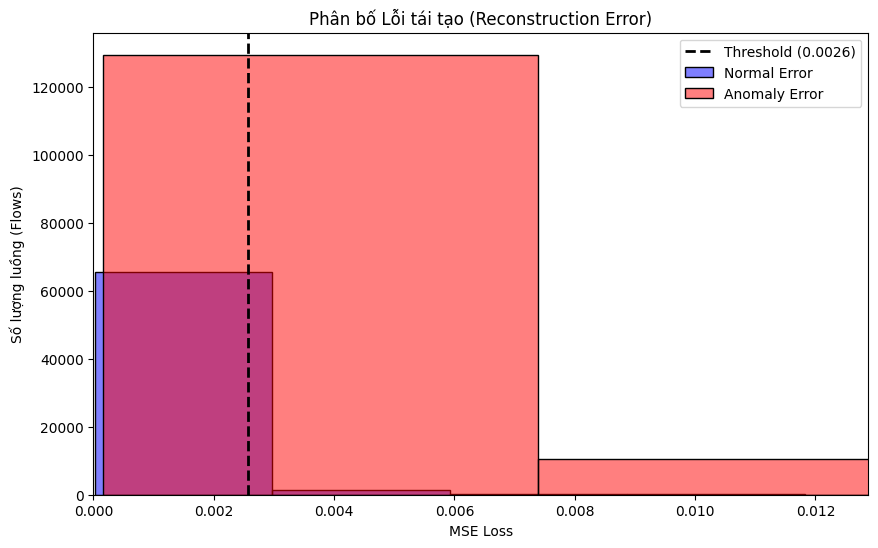

In [10]:
# Cell 7: Đánh giá và tìm Threshold
model_ae.eval()

with torch.no_grad():
    # 1. Tính toán lỗi của toàn bộ tập Normal để làm Hệ quy chiếu
    X_train_device = X_train_tensor.to(device)
    train_preds = model_ae(X_train_device)
    # Lỗi MSE cho từng mẫu
    train_mse_loss = torch.mean((train_preds - X_train_device)**2, dim=1).cpu().numpy()

    # Đặt ngưỡng: Lấy phần vị phân thứ 95 hoặc Mean + 3*Std
    # percentile=95 có nghĩa là ta chấp nhận rủi ro báo nhầm 5% normal để bắt chặn đứt các luồng tấn công
    threshold = np.percentile(train_mse_loss, 95)
    print(f"Ngưỡng Lỗi tái tạo (Threshold) được thiết lập tại: {threshold:.6f}\n")

    # 2. Quét qua toàn bộ tập Test (Gồm cả Normal và Tấn công)
    test_preds = model_ae(X_test_tensor)
    test_mse_loss = torch.mean((test_preds - X_test_tensor)**2, dim=1).cpu().numpy()

    # 3. Phân loại: Lỗi > Threshold => Anomaly (1), ngược lại => Normal (0)
    y_pred = (test_mse_loss > threshold).astype(int)

# Báo cáo kết quả
print("--- BÁO CÁO KẾT QUẢ AUTOENCODER ---")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")

# Vẽ đồ thị phân bố lỗi cực kỳ trực quan cho báo cáo
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(test_mse_loss[y_test == 0], bins=50, color='blue', alpha=0.5, label='Normal Error')
sns.histplot(test_mse_loss[y_test == 1], bins=50, color='red', alpha=0.5, label='Anomaly Error')
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.4f})')
plt.title('Phân bố Lỗi tái tạo (Reconstruction Error)')
plt.xlabel('MSE Loss')
plt.ylabel('Số lượng luồng (Flows)')
plt.legend()
plt.xlim(0, threshold * 5) # Zoom vào vùng quan trọng
plt.show()

In [11]:
# Cell 8: Lưu trọng số
save_path = '/content/drive/MyDrive/Model_InSDN/sdn_autoencoder_model.pth'
torch.save(model_ae.state_dict(), save_path)
print(f"Đã lưu mô hình Autoencoder tại: {save_path}")

Đã lưu mô hình Autoencoder tại: /content/drive/MyDrive/Model_InSDN/sdn_autoencoder_model.pth
